In [187]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator

# **LOAD DATA**

In [188]:
data = torch.load("/home/user-05/isaac_lab_projects/IsaacLab_fork/logs/rsl_rl/data_rollout/rollout_00000999.pt")
obs = data["obs"]
act = data["act"]
rew = data["rew"]
foot_rew_l = data["feet_rew_l"]
foot_rew_r = data["feet_rew_r"]
foot_frc_l = data["feet_frc_l"]
foot_frc_r = data["feet_frc_r"]
foot_spd_l = data["feet_spd_l"]
foot_spd_r = data["feet_spd_r"]
n_foot_frc_l = data["n_feet_frc_l"]
n_foot_frc_r = data["n_feet_frc_r"]
n_foot_spd_l = data["n_feet_spd_l"]
n_foot_spd_r = data["n_feet_spd_r"]
foot_pos_r = data["feet_pos_r"]
foot_pos_l = data["feet_pos_l"]
terminated = data["terminated"]
truncated = data["truncated"]

In [189]:
print(foot_pos_l.size())

torch.Size([1000, 999, 3])


# **PLOTTING**
## **REWARD**
### TOT REWARD AND FEET REWARD OF A SELECTED ENV

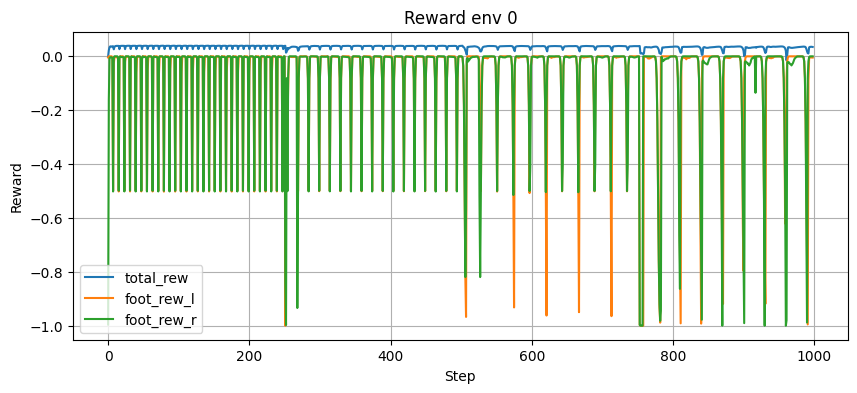

In [190]:
# select environment to plot
env_id = 0

plt.figure(figsize=(10,4))
plt.plot(rew[env_id], label="total_rew")
plt.plot(foot_rew_l[env_id], label="foot_rew_l")
plt.plot(foot_rew_r[env_id], label="foot_rew_r")
plt.legend()
plt.title(f"Reward env {env_id}")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

In [191]:
print("rew dimensions:", rew.shape)

rew dimensions: torch.Size([1000, 999])


### REWARD MEAN AND STD (OR CI)

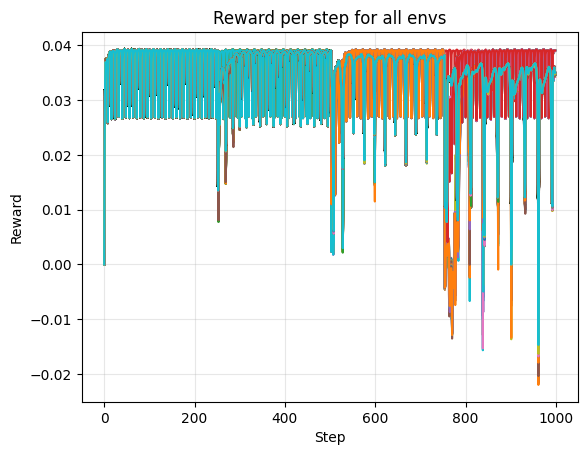

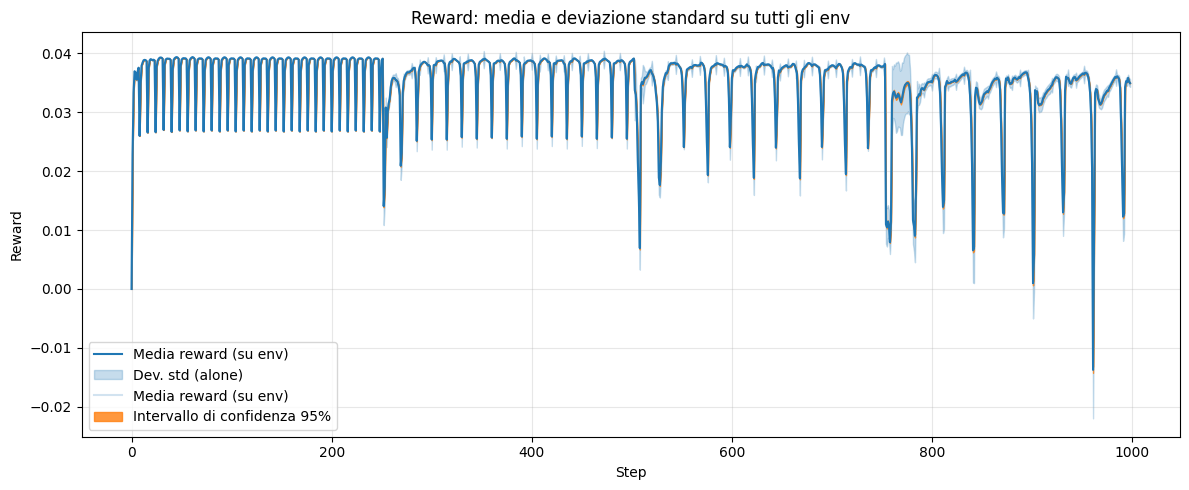

In [192]:
# Converti in numpy per comodità
rew_np = rew.cpu().numpy() if isinstance(rew, torch.Tensor) else np.array(rew)

for env_ids in range(rew_np.shape[0]):
    plt.plot(rew_np[env_ids])
plt.title("Reward per step for all envs")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.show()

# Rendi la forma uniforme: (num_envs, num_steps)
if rew_np.ndim != 2:
    raise ValueError(f"rew ha forma inattesa: {rew_np.shape}")


num_envs, num_steps = rew_np.shape
steps = np.arange(num_steps)

# (Opzionale) Se hai NA/NaN, usa nanmean/nanstd
mean_rew = np.nanmean(rew_np, axis=0)       # media su env per ogni step
std_rew  = np.nanstd(rew_np, axis=0)        # std su env per ogni step
#intervallo di confidenza invece della deviazione standard,  1.96 * std / sqrt(num_envs) per un 95% CI
ci95 = 1.960 * std_rew / np.sqrt(num_envs)

# (Opzionale) smoothing con media mobile per migliorare leggibilità
def moving_average(x, window=25):
    if window is None or window <= 1:
        return x
    # padding riflessivo per non accorciare la serie
    pad = window // 2
    x_pad = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(x_pad, kernel, mode='valid')

smooth_window = 1 #25  # metti None o 1 se non vuoi smoothing
mean_s = moving_average(mean_rew, window=smooth_window)
std_s  = moving_average(std_rew,  window=smooth_window)

# Plot
plt.figure(figsize=(12, 5))
# MEAN e DEVIAZIONE STANDARD
plt.plot(steps, mean_s, color="C0", label="Media reward (su env)")
plt.fill_between(steps, mean_s - std_s, mean_s + std_s, color="C0", alpha=0.25,
                 label="Dev. std (alone)")
# INTERVALLO DI CONFIDENZA 
plt.plot(steps, mean_rew, color="C0", alpha=0.2,label="Media reward (su env)")
plt.fill_between(steps, mean_rew- ci95, mean_rew + ci95, color="C1", alpha=0.8,
                 label="Intervallo di confidenza 95%")
plt.title("Reward: media e deviazione standard su tutti gli env")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## **FOOT FORCES AND VELOCITIES (single env)**

### FORCES (NORMALIZED AND NOT)

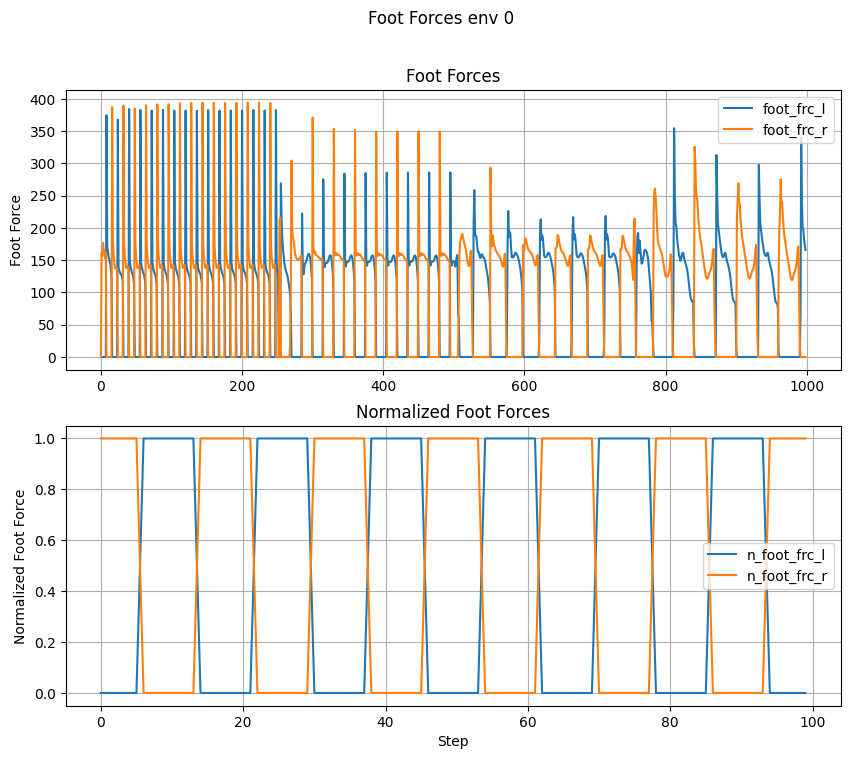

In [193]:
#2 subplots: foot forces an normalized foot forces
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(f"Foot Forces env {env_id}")   
ax1.plot(foot_frc_l[env_id, :], label="foot_frc_l")
ax1.plot(foot_frc_r[env_id, :], label="foot_frc_r")
ax1.set_ylabel("Foot Force")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Foot Forces")
ax2.plot(n_foot_frc_l[env_id, 50:150], label="n_foot_frc_l")
ax2.plot(n_foot_frc_r[env_id, 50:150], label="n_foot_frc_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Force")
ax2.legend()
ax2.grid(True)
ax2.set_title("Normalized Foot Forces")  
plt.show()

### VELOCITIES (NORMALIZED AND NOT)

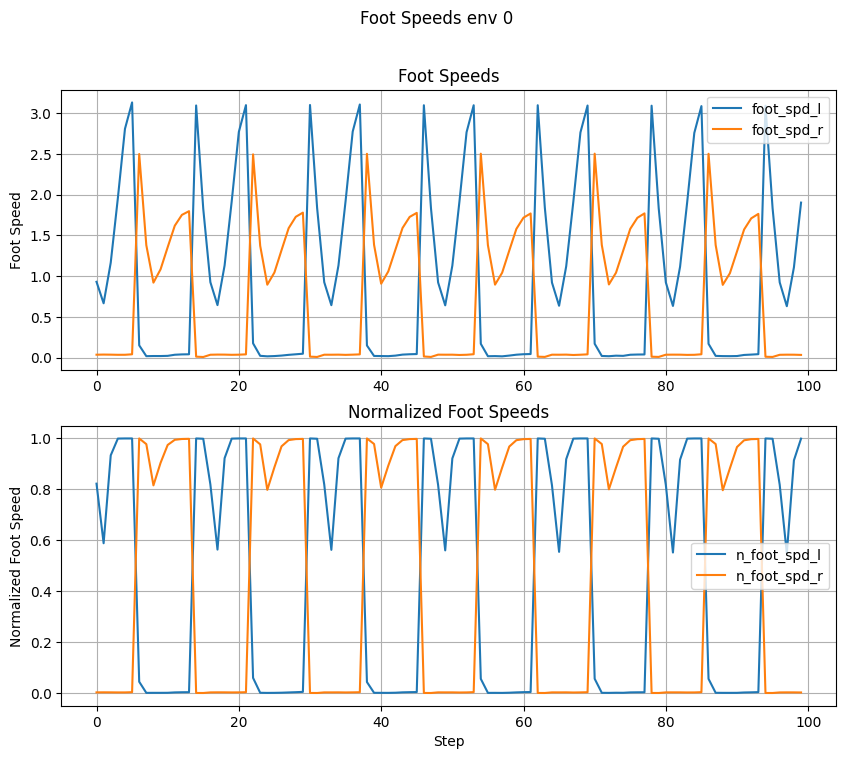

In [194]:
#2 subplots: foot speeds an normalized foot speeds
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(f"Foot Speeds env {env_id}")   
ax1.plot(foot_spd_l[env_id, 50:150], label="foot_spd_l")
ax1.plot(foot_spd_r[env_id, 50:150], label="foot_spd_r")
ax1.set_ylabel("Foot Speed")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Foot Speeds")
ax2.plot(n_foot_spd_l[env_id, 50:150], label="n_foot_spd_l")
ax2.plot(n_foot_spd_r[env_id, 50:150], label="n_foot_spd_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Speed")
ax2.legend()
ax2.grid(True)  
ax2.set_title("Normalized Foot Speeds")
plt.show()

### FOOT FORCES VS VELOCITIES (NORMALIZED AND NOT)

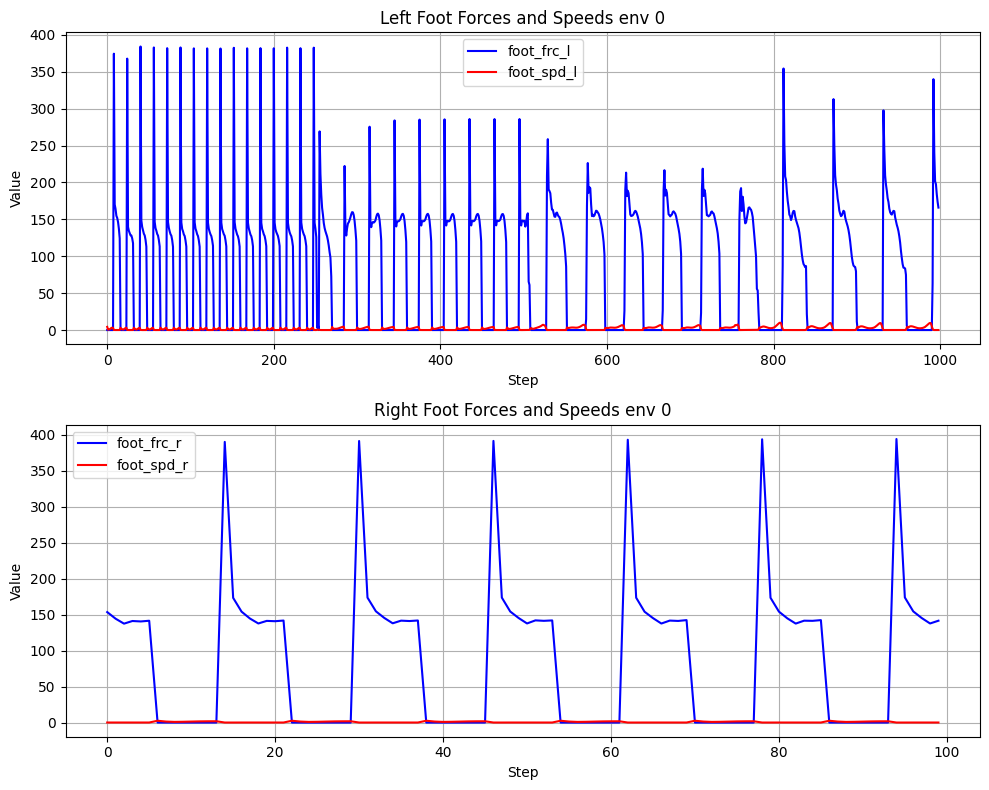

In [195]:
#2 subplots for left and right foot speed vs force
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(foot_frc_l[env_id, :], label="foot_frc_l", color='b')
axs[0].plot(foot_spd_l[env_id, :], label="foot_spd_l", color='r')
axs[0].set_title(f"Left Foot Forces and Speeds env {env_id}")
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Value")
axs[0].legend() 
axs[0].grid(True)
axs[1].plot(foot_frc_r[env_id, 50:150], label="foot_frc_r", color='b')
axs[1].plot(foot_spd_r[env_id, 50:150], label="foot_spd_r", color='r')
axs[1].set_title(f"Right Foot Forces and Speeds env {env_id}")
axs[1].set_xlabel("Step")   
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

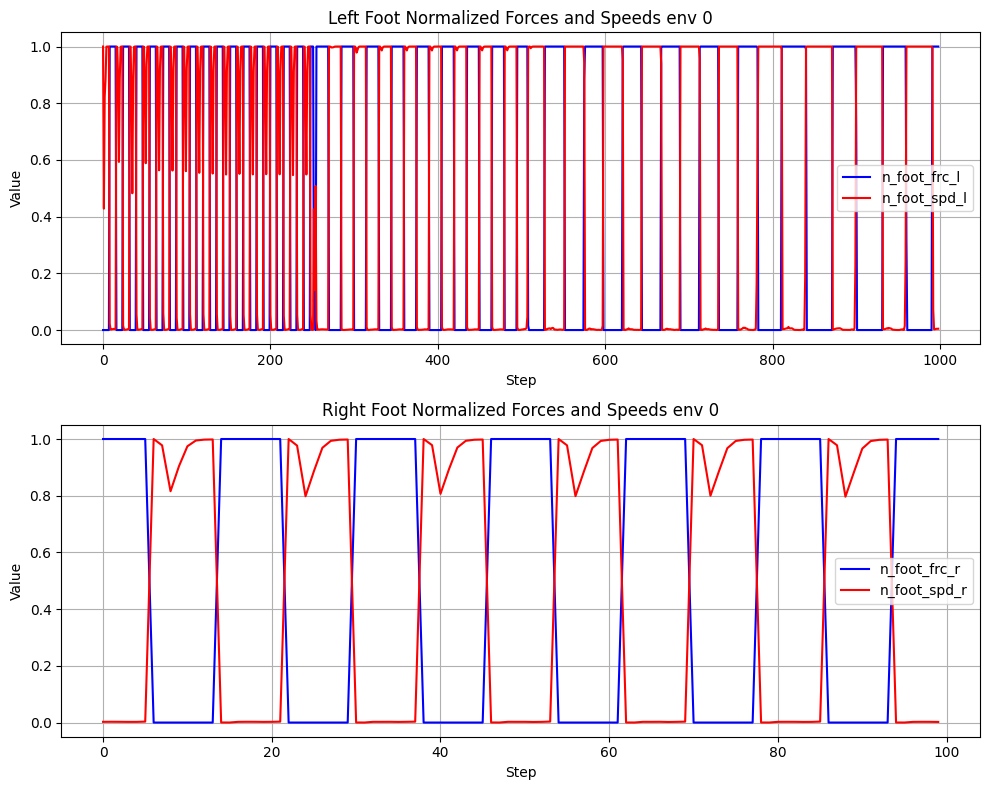

In [196]:
#2 subplots for left and right foot speed vs force (normalized)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(n_foot_frc_l[env_id, :], label="n_foot_frc_l", color='b')
axs[0].plot(n_foot_spd_l[env_id, :], label="n_foot_spd_l", color='r')
axs[0].set_title(f"Left Foot Normalized Forces and Speeds env {env_id}")
axs[0].set_xlabel("Step")       
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(n_foot_frc_r[env_id, 50:150], label="n_foot_frc_r", color='b')
axs[1].plot(n_foot_spd_r[env_id, 50:150], label="n_foot_spd_r", color='r')
axs[1].set_title(f"Right Foot Normalized Forces and Speeds env {env_id}")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

## **FOOT FORCES AND VELOCITIES (all envs)**

### FORCES (NORMALIZED AND NOT)

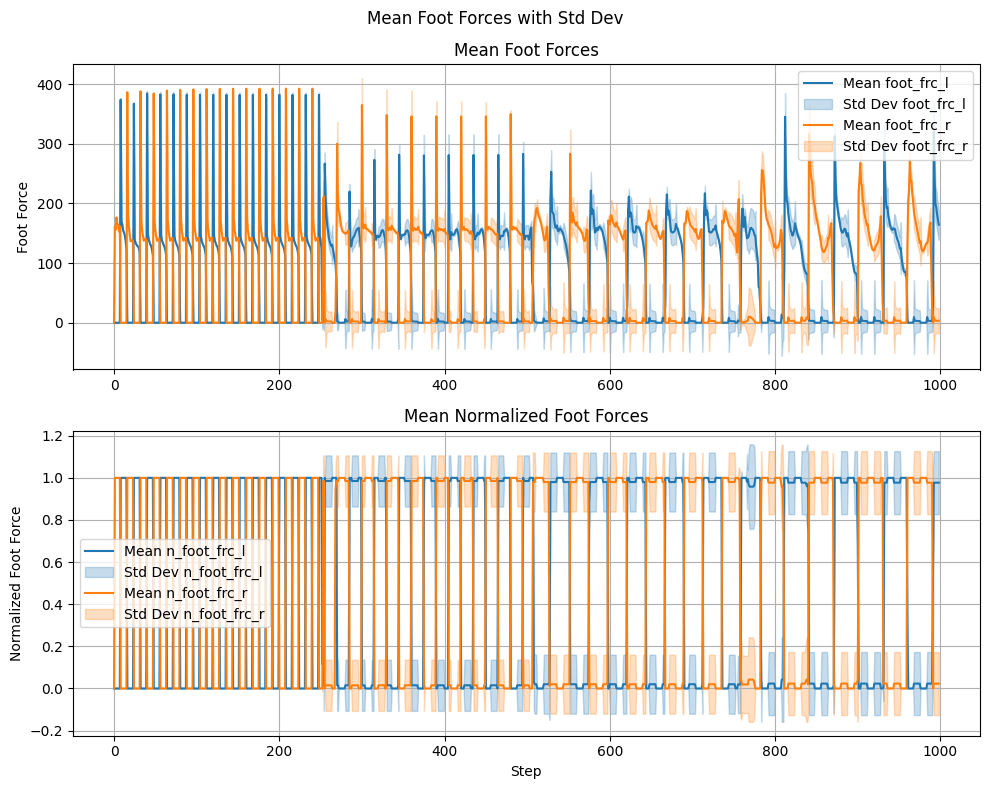

In [197]:

mean_foot_frc_l = np.nanmean(foot_frc_l.cpu().numpy(), axis=0)
mean_foot_frc_r = np.nanmean(foot_frc_r.cpu().numpy(), axis=0)
mean_foot_n_frc_l = np.nanmean(n_foot_frc_l.cpu().numpy(), axis=0)
mean_foot_n_frc_r = np.nanmean(n_foot_frc_r.cpu().numpy(), axis=0)

std_foot_frc_l = np.nanstd(foot_frc_l.cpu().numpy(), axis=0)
std_foot_frc_r = np.nanstd(foot_frc_r.cpu().numpy(), axis=0)
std_foot_n_frc_l = np.nanstd(n_foot_frc_l.cpu().numpy(), axis=0)
std_foot_n_frc_r = np.nanstd(n_foot_frc_r.cpu().numpy(), axis=0)

# ci95_foot_frc_l = 1.960 * std_foot_frc_l / np.sqrt(num_envs)
# ci95_foot_frc_r = 1.960 * std_foot_frc_r / np.sqrt(num_envs)
# ci95_foot_n_frc_l = 1.960 * std_foot_n_frc_l / np.sqrt(num_envs)
# ci95_foot_n_frc_r = 1.960 * std_foot_n_frc_r / np.sqrt(num_envs)

# 2 subplots: mean foot forces and normalized mean foot forces with std shading
#from step 50 to 90
# mean_foot_frc_l = mean_foot_frc_l[50:90]
# mean_foot_frc_r = mean_foot_frc_r[50:90]
# mean_foot_n_frc_l = mean_foot_n_frc_l[50:90]
# mean_foot_n_frc_r = mean_foot_n_frc_r[50:90]

# std_foot_frc_l = std_foot_frc_l[50:90]
# std_foot_frc_r = std_foot_frc_r[50:90]
# std_foot_n_frc_l = std_foot_n_frc_l[50:90]
# std_foot_n_frc_r = std_foot_n_frc_r[50:90]

mean_foot_frc_l = mean_foot_frc_l[:]
mean_foot_frc_r = mean_foot_frc_r[:]
mean_foot_n_frc_l = mean_foot_n_frc_l[:]
mean_foot_n_frc_r = mean_foot_n_frc_r[:]

std_foot_frc_l = std_foot_frc_l[:]
std_foot_frc_r = std_foot_frc_r[:]
std_foot_n_frc_l = std_foot_n_frc_l[:]
std_foot_n_frc_r = std_foot_n_frc_r[:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Mean Foot Forces with Std Dev")   
ax1.plot(mean_foot_frc_l, label="Mean foot_frc_l")
ax1.fill_between(np.arange(len(mean_foot_frc_l)), mean_foot_frc_l - std_foot_frc_l, mean_foot_frc_l + std_foot_frc_l, color="C0", alpha=0.25,
                 label="Std Dev foot_frc_l")
ax1.plot(mean_foot_frc_r, label="Mean foot_frc_r")
ax1.fill_between(np.arange(len(mean_foot_frc_r)), mean_foot_frc_r - std_foot_frc_r, mean_foot_frc_r + std_foot_frc_r, color="C1", alpha=0.25,
                 label="Std Dev foot_frc_r")
ax1.set_ylabel("Foot Force")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Mean Foot Forces")
ax2.plot(mean_foot_n_frc_l, label="Mean n_foot_frc_l")
ax2.fill_between(np.arange(len(mean_foot_n_frc_l)), mean_foot_n_frc_l - std_foot_n_frc_l, mean_foot_n_frc_l + std_foot_n_frc_l, color="C0", alpha=0.25,
                    label="Std Dev n_foot_frc_l")
ax2.plot(mean_foot_n_frc_r, label="Mean n_foot_frc_r")
ax2.fill_between(np.arange(len(mean_foot_n_frc_r)), mean_foot_n_frc_r - std_foot_n_frc_r, mean_foot_n_frc_r + std_foot_n_frc_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_frc_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Force")
ax2.legend()
ax2.grid(True)
ax2.set_title("Mean Normalized Foot Forces")  
plt.tight_layout()
plt.show()  

### VELOCITIES (NORMALIZED AND NOT)

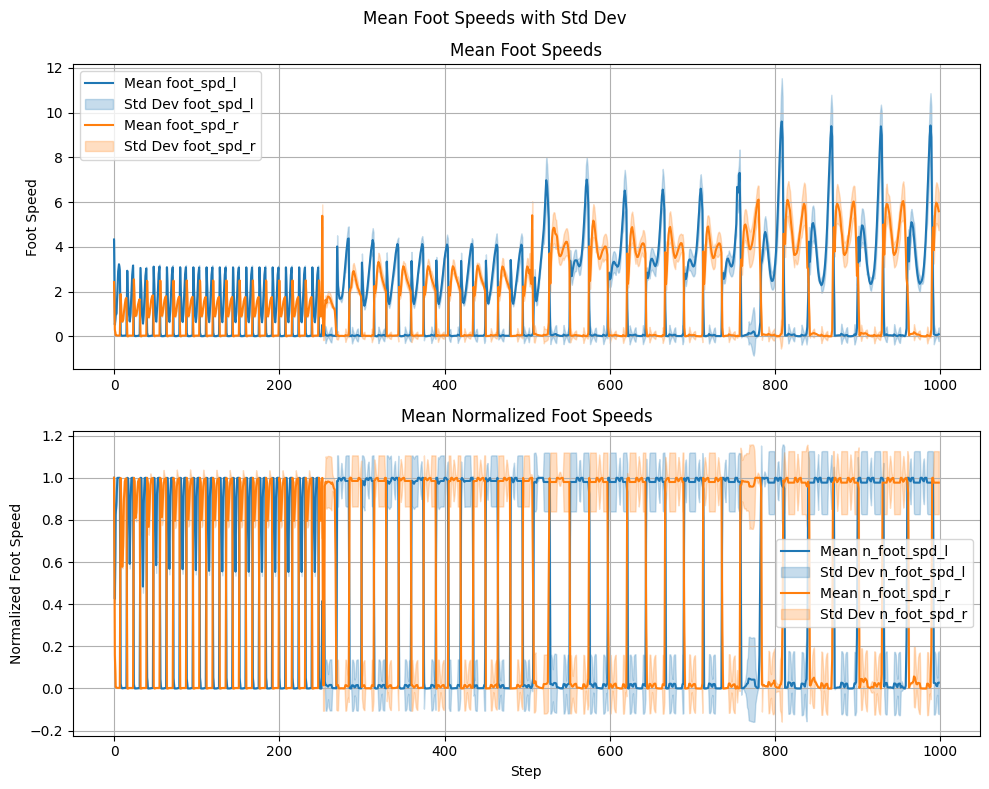

In [198]:
mean_foot_spd_l = np.nanmean(foot_spd_l.cpu().numpy(), axis=0)
mean_foot_spd_r = np.nanmean(foot_spd_r.cpu().numpy(), axis=0)
mean_foot_n_spd_l = np.nanmean(n_foot_spd_l.cpu().numpy(), axis=0)
mean_foot_n_spd_r = np.nanmean(n_foot_spd_r.cpu().numpy(), axis=0)

std_foot_spd_l = np.nanstd(foot_spd_l.cpu().numpy(), axis=0)
std_foot_spd_r = np.nanstd(foot_spd_r.cpu().numpy(), axis=0)
std_foot_n_spd_l = np.nanstd(n_foot_spd_l.cpu().numpy(), axis=0)
std_foot_n_spd_r = np.nanstd(n_foot_spd_r.cpu().numpy(), axis=0)

# ci95_foot_spd_l = 1.960 * std_foot_spd_l / np.sqrt(num_envs)
# ci95_foot_spd_r = 1.960 * std_foot_spd_r / np.sqrt(num_envs)
# ci95_foot_n_spd_l = 1.960 * std_foot_n_spd_l / np.sqrt(num_envs)
# ci95_foot_n_spd_r = 1.960 * std_foot_n_spd_r / np.sqrt(num_envs)

# 2 subplots: mean foot speeds and normalized mean foot speeds with std shading
#from step 50 to 90
# mean_foot_spd_l = mean_foot_spd_l[50:90]
# mean_foot_spd_r = mean_foot_spd_r[50:90]
# mean_foot_n_spd_l = mean_foot_n_spd_l[50:90]
# mean_foot_n_spd_r = mean_foot_n_spd_r[50:90]

# std_foot_spd_l = std_foot_spd_l[50:90]
# std_foot_spd_r = std_foot_spd_r[50:90]
# std_foot_n_spd_l = std_foot_n_spd_l[50:90]
# std_foot_n_spd_r = std_foot_n_spd_r[50:90]


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Mean Foot Speeds with Std Dev")   
ax1.plot(mean_foot_spd_l, label="Mean foot_spd_l")
ax1.fill_between(np.arange(len(mean_foot_spd_l)), mean_foot_spd_l - std_foot_spd_l, mean_foot_spd_l + std_foot_spd_l, color="C0", alpha=0.25,
                 label="Std Dev foot_spd_l")
ax1.plot(mean_foot_spd_r, label="Mean foot_spd_r")
ax1.fill_between(np.arange(len(mean_foot_spd_r)), mean_foot_spd_r - std_foot_spd_r, mean_foot_spd_r + std_foot_spd_r, color="C1", alpha=0.25,
                 label="Std Dev foot_spd_r")
ax1.set_ylabel("Foot Speed")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Mean Foot Speeds")
ax2.plot(mean_foot_n_spd_l, label="Mean n_foot_spd_l")
ax2.fill_between(np.arange(len(mean_foot_n_spd_l)), mean_foot_n_spd_l - std_foot_n_spd_l, mean_foot_n_spd_l + std_foot_n_spd_l, color="C0", alpha=0.25,     
                    label="Std Dev n_foot_spd_l")
ax2.plot(mean_foot_n_spd_r, label="Mean n_foot_spd_r")
ax2.fill_between(np.arange(len(mean_foot_n_spd_r)), mean_foot_n_spd_r - std_foot_n_spd_r, mean_foot_n_spd_r + std_foot_n_spd_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_spd_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Speed")
ax2.legend()
ax2.grid(True)
ax2.set_title("Mean Normalized Foot Speeds")  
plt.tight_layout()
plt.show()  

### FOOT FORCES VS VELOCITIES (NORMALIZED AND NOT)

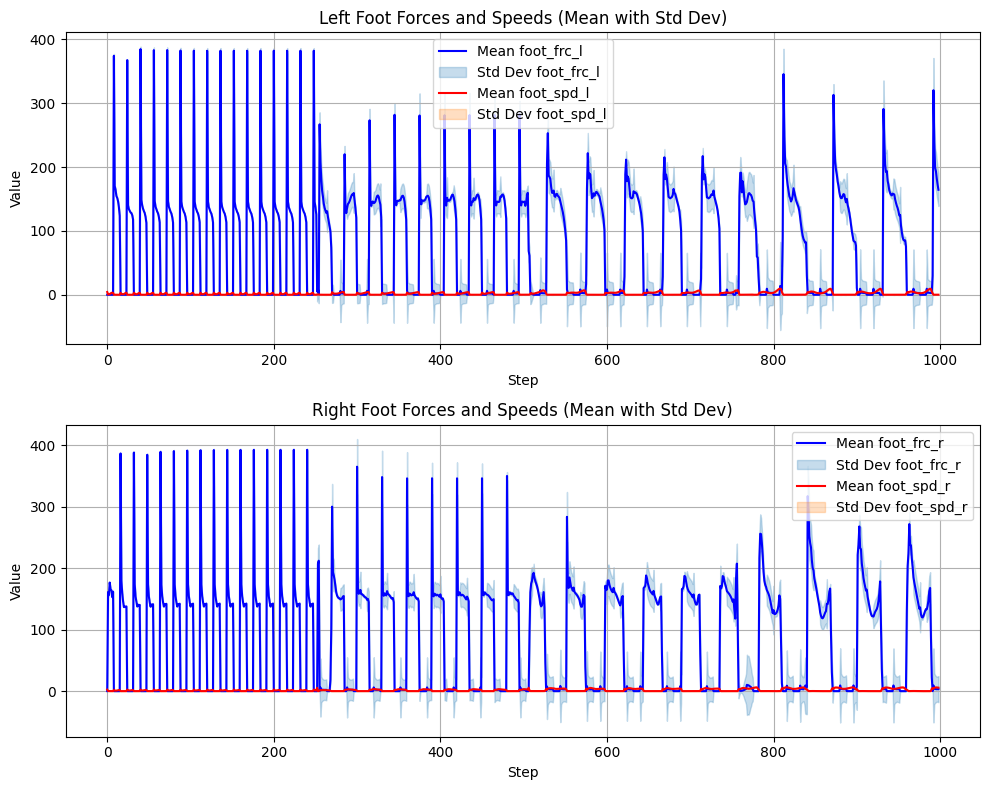

In [199]:
#2 subplots for left and right foot speed vs force with mean values and std shading
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(mean_foot_frc_l, label="Mean foot_frc_l", color='b')
axs[0].fill_between(np.arange(len(mean_foot_frc_l)), mean_foot_frc_l - std_foot_frc_l, mean_foot_frc_l + std_foot_frc_l, color="C0", alpha=0.25,
                 label="Std Dev foot_frc_l")
axs[0].plot(mean_foot_spd_l, label="Mean foot_spd_l", color='r')
axs[0].fill_between(np.arange(len(mean_foot_spd_l)), mean_foot_spd_l - std_foot_spd_l, mean_foot_spd_l + std_foot_spd_l, color="C1", alpha=0.25,
                 label="Std Dev foot_spd_l")
axs[0].set_title("Left Foot Forces and Speeds (Mean with Std Dev)")
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(mean_foot_frc_r, label="Mean foot_frc_r", color='b')
axs[1].fill_between(np.arange(len(mean_foot_frc_r)), mean_foot_frc_r - std_foot_frc_r, mean_foot_frc_r + std_foot_frc_r, color="C0", alpha=0.25,
                    label="Std Dev foot_frc_r") 
axs[1].plot(mean_foot_spd_r, label="Mean foot_spd_r", color='r')
axs[1].fill_between(np.arange(len(mean_foot_spd_r)), mean_foot_spd_r - std_foot_spd_r, mean_foot_spd_r + std_foot_spd_r, color="C1", alpha=0.25,
                    label="Std Dev foot_spd_r") 
axs[1].set_title("Right Foot Forces and Speeds (Mean with Std Dev)")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()  

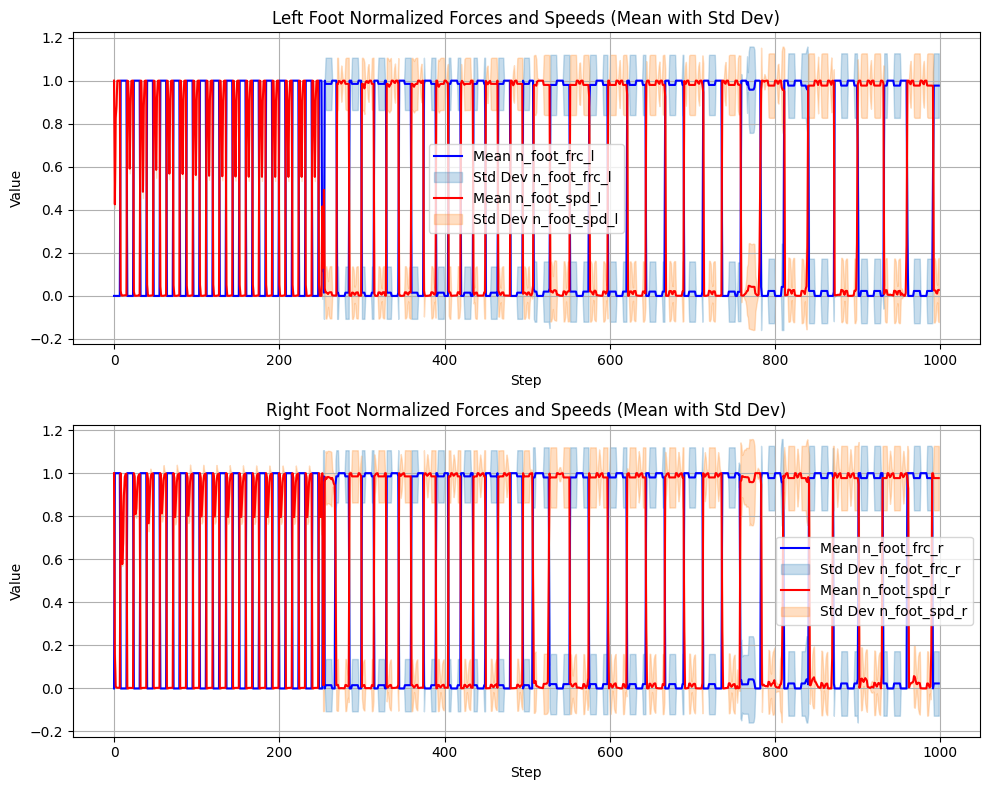

In [200]:
#2 subplots for left and right foot speed vs force with mean values and std shading (normalized)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(mean_foot_n_frc_l, label="Mean n_foot_frc_l", color='b')
axs[0].fill_between(np.arange(len(mean_foot_n_frc_l)), mean_foot_n_frc_l - std_foot_n_frc_l, mean_foot_n_frc_l + std_foot_n_frc_l, color="C0", alpha=0.25,
                 label="Std Dev n_foot_frc_l")
axs[0].plot(mean_foot_n_spd_l, label="Mean n_foot_spd_l", color='r')
axs[0].fill_between(np.arange(len(mean_foot_n_spd_l)), mean_foot_n_spd_l - std_foot_n_spd_l , mean_foot_n_spd_l + std_foot_n_spd_l, color="C1", alpha=0.25,
                 label="Std Dev n_foot_spd_l")
axs[0].set_title("Left Foot Normalized Forces and Speeds (Mean with Std Dev)")
axs[0].set_xlabel("Step")       
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(mean_foot_n_frc_r, label="Mean n_foot_frc_r", color='b')
axs[1].fill_between(np.arange(len(mean_foot_n_frc_r)), mean_foot_n_frc_r - std_foot_n_frc_r, mean_foot_n_frc_r + std_foot_n_frc_r, color="C0", alpha=0.25,
                    label="Std Dev n_foot_frc_r") 
axs[1].plot(mean_foot_n_spd_r, label="Mean n_foot_spd_r", color='r')
axs[1].fill_between(np.arange(len(mean_foot_n_spd_r)), mean_foot_n_spd_r - std_foot_n_spd_r, mean_foot_n_spd_r + std_foot_n_spd_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_spd_r") 
axs[1].set_title("Right Foot Normalized Forces and Speeds (Mean with Std Dev)")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()


## **OBSERVATIONS**

### LINEAR POSITIONS OF THE PELVIS

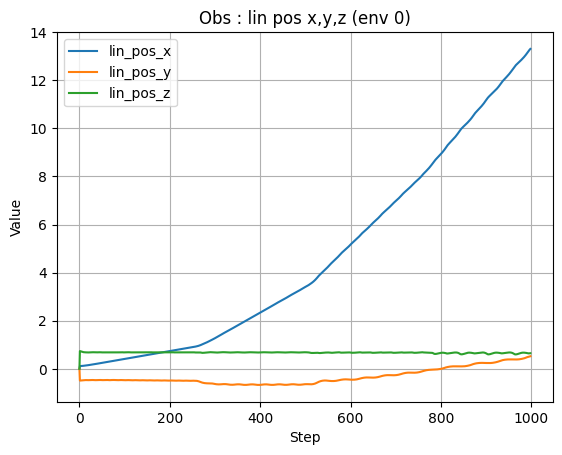

In [201]:

plt.plot(obs[env_id, :, -7:-4])
plt.legend(['lin_pos_x', 'lin_pos_y', 'lin_pos_z'])
plt.title(f"Obs : lin pos x,y,z (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

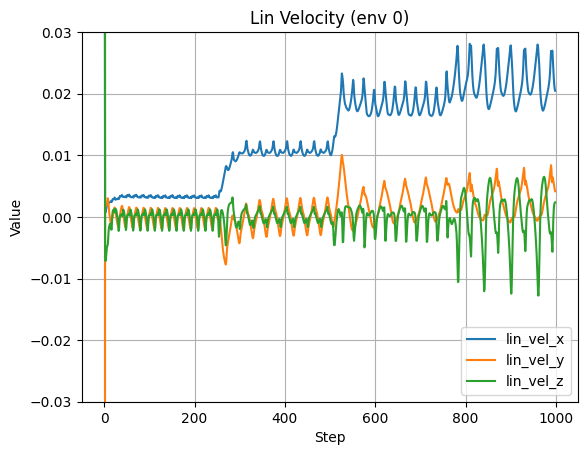

In [202]:
#compute and plot the derivative of the position (velocity)
lin_pos = obs[env_id, :, -7:-4].cpu().numpy()
lin_vel = np.gradient(lin_pos, axis=0)  # derivative along the time axis
plt.plot(lin_vel)
plt.legend(['lin_vel_x', 'lin_vel_y', 'lin_vel_z'])
plt.title(f"Lin Velocity (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.ylim(-0.03, 0.03)
plt.grid(True)
plt.show()

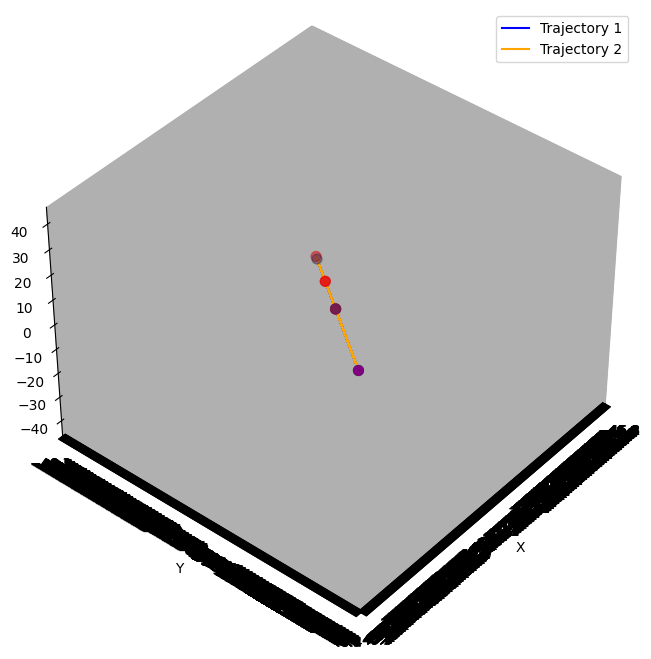

In [203]:
# =========================
#  Tensori di esempio
# =========================
# Qui userai i tuoi veri tensori
trajectory1 = foot_pos_l[:,0:600,:].squeeze(0)   # shape (T1, 3)
trajectory2 = foot_pos_r[:,0:600,:].squeeze(0)   # shape (T2, 3)

# separo coordinate
x1, y1, z1 = trajectory1[:,0], trajectory1[:,1], trajectory1[:,2]
x2, y2, z2 = trajectory2[:,0], trajectory2[:,1], trajectory2[:,2]

# =========================
#   FIGURE PIÙ GRANDE
# =========================
fig = plt.figure(figsize=(12, 8))   # <--- aumenta la dimensione
ax = fig.add_subplot(111, projection='3d')

# =========================
#   PLOT DELLE 2 TRAIETTORIE
# =========================
ax.plot(x1, y1, z1, label='Trajectory 1', color='blue')
ax.plot(x2, y2, z2, label='Trajectory 2', color='orange')

# punti iniziali/finali opzionali
ax.scatter(x1[0], y1[0], z1[0], color='green', s=50)   # start traj1
ax.scatter(x1[-1], y1[-1], z1[-1], color='red', s=50)  # end traj1

ax.scatter(x2[0], y2[0], z2[0], color='purple', s=50)  # start traj2
ax.scatter(x2[-1], y2[-1], z2[-1], color='brown', s=50) # end traj2

# =========================
#   PUNTO DI VISTA (opzionale)
# =========================
ax.view_init(elev=40, azim=40)

x_tick_step = 0.1
ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))

# 2) Applica lo stesso passo a Y
ax.yaxis.set_major_locator(MultipleLocator(x_tick_step))


# Calcola i limiti attuali dopo aver plottato
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Trova il range massimo e centra entrambi gli assi sullo stesso range
max_range = max(x_max - x_min, y_max - y_min)
x_center = 0.5 * (x_max + x_min)
y_center = 0.5 * (y_max + y_min)

ax.set_xlim(x_center - max_range/2, x_center + max_range/2)
ax.set_ylim(y_center - max_range/2, y_center + max_range/2)



# labels + legenda
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

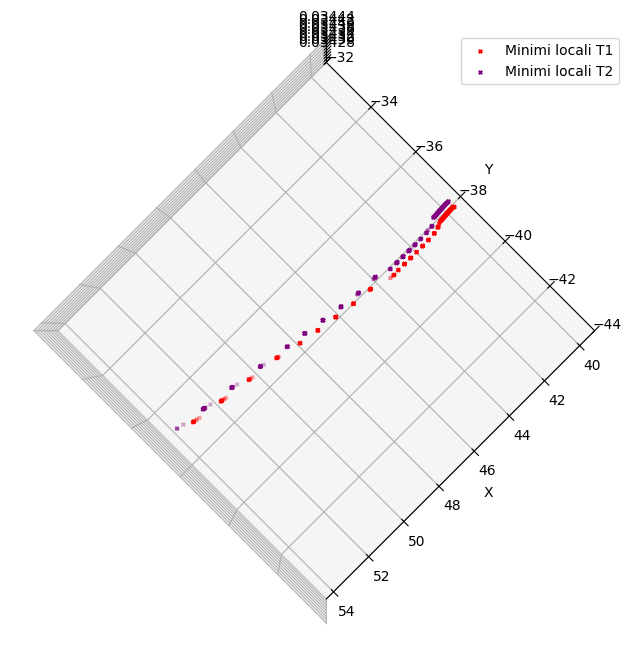

In [211]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------------------------
# Funzione per trovare i minimi locali su un vettore 1D
# -----------------------------------------------------
def local_minima_indices(x):
    # x è un tensore 1D (T,)
    return torch.where(
        (x[1:-1] < x[:-2]) & (x[1:-1] < x[2:]) & (x[1:-1]<0.05)
    )[0] + 1


# -----------------------------------------------------
# Carica le tue traiettorie (forma attesa: (1, T, 3))
# -----------------------------------------------------
traj1 = foot_pos_r[env_id,:,:].squeeze(0)   # (T1, 3)
traj2 = foot_pos_l[env_id,:,:].squeeze(0)   # (T2, 3)

# Estrai coordinate
x1, y1, z1 = traj1[:, 0], traj1[:, 1], traj1[:, 2]
x2, y2, z2 = traj2[:, 0], traj2[:, 1], traj2[:, 2]

# -----------------------------------------------------
# Trova i minimi locali su asse Z
# -----------------------------------------------------
min_idx1 = local_minima_indices(z1)
min_idx2 = local_minima_indices(z2)

# -----------------------------------------------------
# Plot 3D
# -----------------------------------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Traiettorie
# ax.plot(x1, y1, z1, label='Traiettoria 1', color='blue')
# ax.plot(x2, y2, z2, label='Traiettoria 2', color='orange')

# Minimi locali evidenziati
ax.scatter(x1[min_idx1], y1[min_idx1], z1[min_idx1],
           color='red', s=6, label='Minimi locali T1', marker='x')

ax.scatter(x2[min_idx2], y2[min_idx2], z2[min_idx2],
           color='purple', s=6, label='Minimi locali T2', marker='x')

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

ax.set_ylim((-32,-44))

# Punto di vista (personalizzabile)
ax.view_init(elev=90, azim=45)

plt.show()



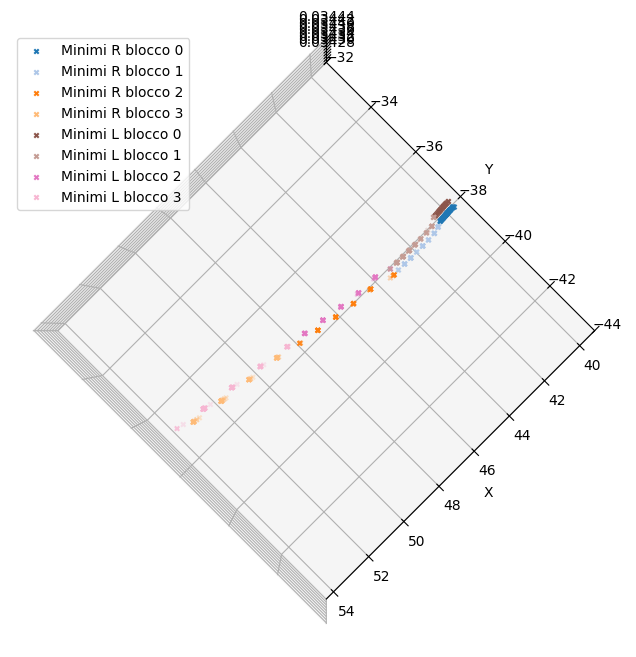

In [218]:
import matplotlib.pyplot as plt
import torch

# -----------------------------------------------------
# Funzione per trovare i minimi locali su un vettore 1D
# -----------------------------------------------------
def local_minima_indices(x):
    return torch.where(
        (x[1:-1] < x[:-2]) & (x[1:-1] < x[2:]) & (x[1:-1] < 0.05)
    )[0] + 1


# -----------------------------------------------------
# Coordinate piedi
# -----------------------------------------------------
traj1 = foot_pos_r[env_id,:,:].squeeze(0)
traj2 = foot_pos_l[env_id,:,:].squeeze(0)

x1, y1, z1 = traj1[:, 0], traj1[:, 1], traj1[:, 2]
x2, y2, z2 = traj2[:, 0], traj2[:, 1], traj2[:, 2]

min_idx1 = local_minima_indices(z1)
min_idx2 = local_minima_indices(z2)

# -----------------------------------------------------
# Funzione per dividere gli indici in blocchi da N timestep
# -----------------------------------------------------
def split_by_timestep(indices, block_size):
    blocks = []
    current = []

    for idx in indices:
        if len(current) == 0:
            current.append(idx)
        else:
            # se è nello stesso blocco temporale, aggiungilo
            if (idx // block_size) == (current[0] // block_size):
                current.append(idx)
            else:
                blocks.append(current)
                current = [idx]

    if len(current) > 0:
        blocks.append(current)

    return blocks


# Suddividi in blocchi da 250 timestep
blocks1 = split_by_timestep(min_idx1, 250)
blocks2 = split_by_timestep(min_idx2, 250)

# Colori automatici
colors = plt.cm.tab20

# -----------------------------------------------------
# Plot
# -----------------------------------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotta traiettorie (se vuoi vederle)
# ax.plot(x1, y1, z1, color='blue', alpha=0.3)
# ax.plot(x2, y2, z2, color='orange', alpha=0.3)

# Plotta i minimi per blocchi
for i, block in enumerate(blocks1):
    idxs = torch.tensor(block)
    ax.scatter(x1[idxs], y1[idxs], z1[idxs],
               color=colors(i % 20),
               s=10, marker='x',
               label=f"Minimi R blocco {i}")

for i, block in enumerate(blocks2):
    idxs = torch.tensor(block)
    ax.scatter(x2[idxs], y2[idxs], z2[idxs],
               color=colors((i+10) % 20),
               s=10, marker='x',
               label=f"Minimi L blocco {i}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_ylim((-32, -44))
ax.view_init(elev=90, azim=45)
ax.legend()
plt.show()

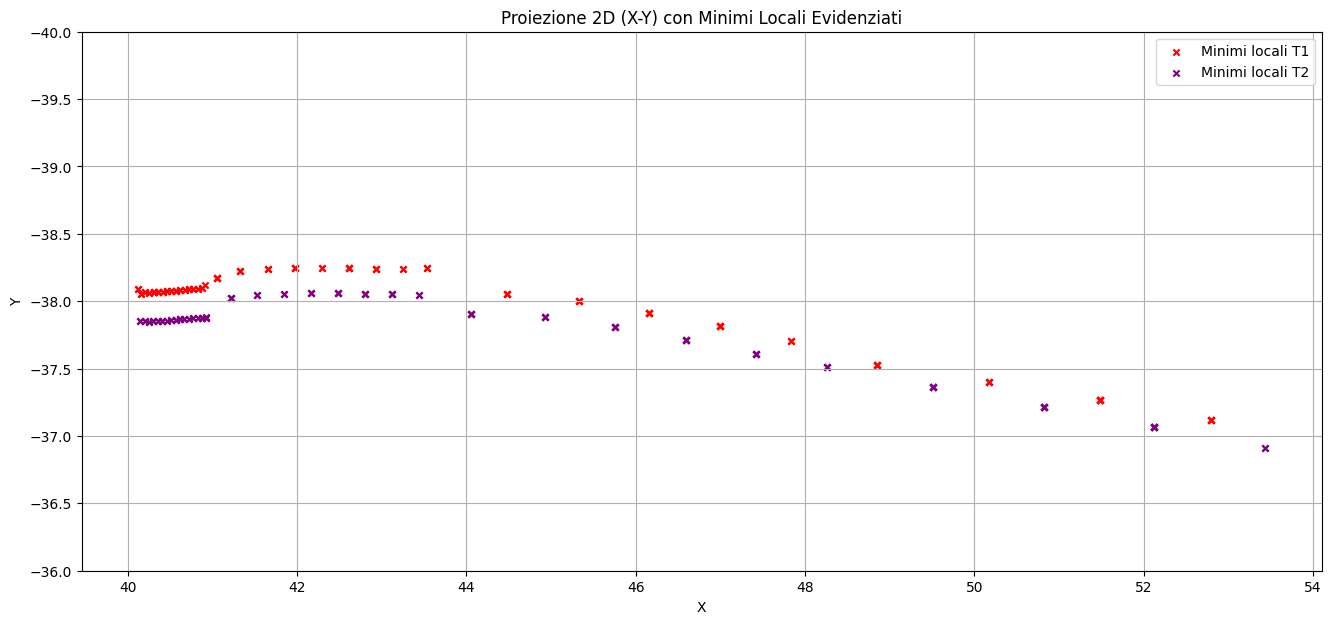

In [ ]:


vx = obs[env_id,:,0]  # velocità X nel tempo
vy = obs[env_id,:,1]   # velocità Y nel tempo

# -----------------------------------------------------
# Plot 2D (X-Y)
# -----------------------------------------------------
plt.figure(figsize=(16, 7))

# Traiettorie opzionali (se le vuoi vedere in 2D, decommenta)
# plt.plot(x1, y1, label='Traiettoria 1', color='blue', alpha=0.6)
# plt.plot(x2, y2, label='Traiettoria 2', color='orange', alpha=0.6)

# Minimi locali evidenziati
plt.scatter(x1[min_idx1], y1[min_idx1],
            color='red', s=20, label='Minimi locali T1', marker='x')

plt.scatter(x2[min_idx2], y2[min_idx2],
            color='purple', s=20, label='Minimi locali T2', marker='x')


# skip = 10  # per non plottare una freccia ogni singolo frame
# plt.quiver(
#     x1[::skip], y1[::skip],   # punto di origine
#     vx[::skip], vy[::skip],   # componente vettore
#     color='green', scale=30, width=0.002, label="Velocità comandata"
# )


plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.ylim((-36, -40))  # come nel plot 3D

plt.title("Proiezione 2D (X-Y) con Minimi Locali Evidenziati")
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


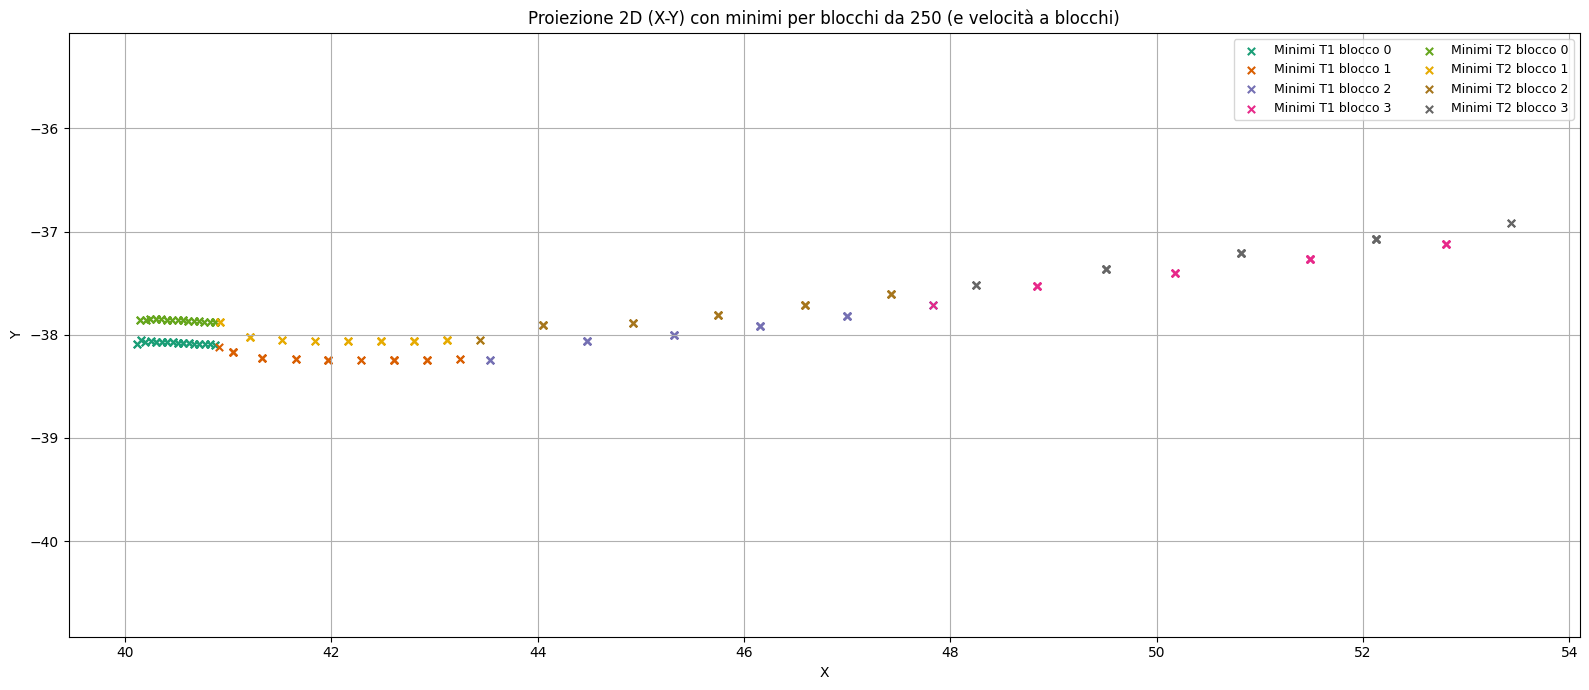

In [243]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Utility: split per blocchi
# -----------------------------
def split_by_timestep(indices, block_size):
    """
    indices: tensore/lista di indici (ordinati) dei minimi
    block_size: numero di timestep per blocco (es. 250)
    Ritorna una lista di liste di indici, uno per blocco.
    """
    if len(indices) == 0:
        return []

    # Assicuriamoci che sia array 1D di interi su CPU
    if hasattr(indices, "cpu"):
        indices = indices.cpu().numpy()
    else:
        indices = np.asarray(indices)

    blocks = []
    current = [indices[0]]
    base_block = indices[0] // block_size

    for idx in indices[1:]:
        block = idx // block_size
        if block == base_block:
            current.append(idx)
        else:
            blocks.append(current)
            current = [idx]
            base_block = block
    blocks.append(current)
    return blocks


# -----------------------------------
# Dati (assumo che siano tensori)
# -----------------------------------
# vx, vy già definiti nel tuo codice:
# vx = obs[env_id,:,0]
# vy = obs[env_id,:,1]

# x1, y1, x2, y2 e min_idx1, min_idx2 già calcolati nel codice precedente

# Converti in NumPy per sicurezza (se sono tensori PyTorch)
to_np = lambda t: t.detach().cpu().numpy() if hasattr(t, "detach") else np.asarray(t)
x1_np, y1_np = to_np(x1), to_np(y1)
x2_np, y2_np = to_np(x2), to_np(y2)
vx_np, vy_np = to_np(vx), to_np(vy)

# Suddivisione dei minimi in blocchi da 250 timestep
BLOCK = 250
blocks1 = split_by_timestep(min_idx1, BLOCK)
blocks2 = split_by_timestep(min_idx2, BLOCK)

# Palette colori
cmap = plt.cm.Dark2  # 20 colori distinti
# -----------------------------------------------------
# Plot 2D (X-Y)
# -----------------------------------------------------
plt.figure(figsize=(16, 7))

# (Opzionale) traiettorie
# plt.plot(x1_np, y1_np, label='Traiettoria 1', color='C0', alpha=0.3)
# plt.plot(x2_np, y2_np, label='Traiettoria 2', color='C1', alpha=0.3)

# Minimi locali colorati per blocchi
for i, block in enumerate(blocks1):
    block = np.asarray(block, dtype=int)
    if block.size == 0: 
        continue
    plt.scatter(x1_np[block], y1_np[block], color=cmap(i ),
                s=28, marker='x', label=f"Minimi T1 blocco {i}")

for i, block in enumerate(blocks2):
    block = np.asarray(block, dtype=int)
    if block.size == 0:
        continue
    # offset di 10 per differenziare i colori dalla serie T1
    plt.scatter(x2_np[block], y2_np[block], color=cmap((i + 4)),
                s=28, marker='x', label=f"Minimi T2 blocco {i}")

# -----------------------------------------------------
# (Opzionale) VETTORI VELOCITÀ (quiver) a blocchi
# -----------------------------------------------------
# plot_quiver = True  # metti False se non ti servono
# if plot_quiver:
#     skip = 10  # freccia ogni 10 frame per non affollare
#     # Per ogni blocco temporale dell'intera sequenza (non solo minimi)
#     T = len(x1_np)
#     n_blocks = int(np.ceil(T / BLOCK))
#     for b in range(n_blocks):
#         start = b * BLOCK
#         end   = min((b + 1) * BLOCK, T)

#         # slicing con skip
#         xx = x1_np[start:end:skip]
#         yy = y1_np[start:end:skip]
#         uvx = vx_np[start:end:skip]
#         uvy = vy_np[start:end:skip]

#         if len(xx) == 0:
#             continue

        # plt.quiver(
        #     xx, yy, uvx, uvy,
        #     color=cmap(b % 20),
        #     scale=30, width=0.002, alpha=0.9,
        #     label=f"Vel. blocco {b}" if b < 2 else None  # evitare troppi duplicati in legenda
        # )

plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")

# Attenzione: qui conviene mettere ymin < ymax
plt.ylim(-40, -36)

plt.title("Proiezione 2D (X-Y) con minimi per blocchi da 250 (e velocità a blocchi)")
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

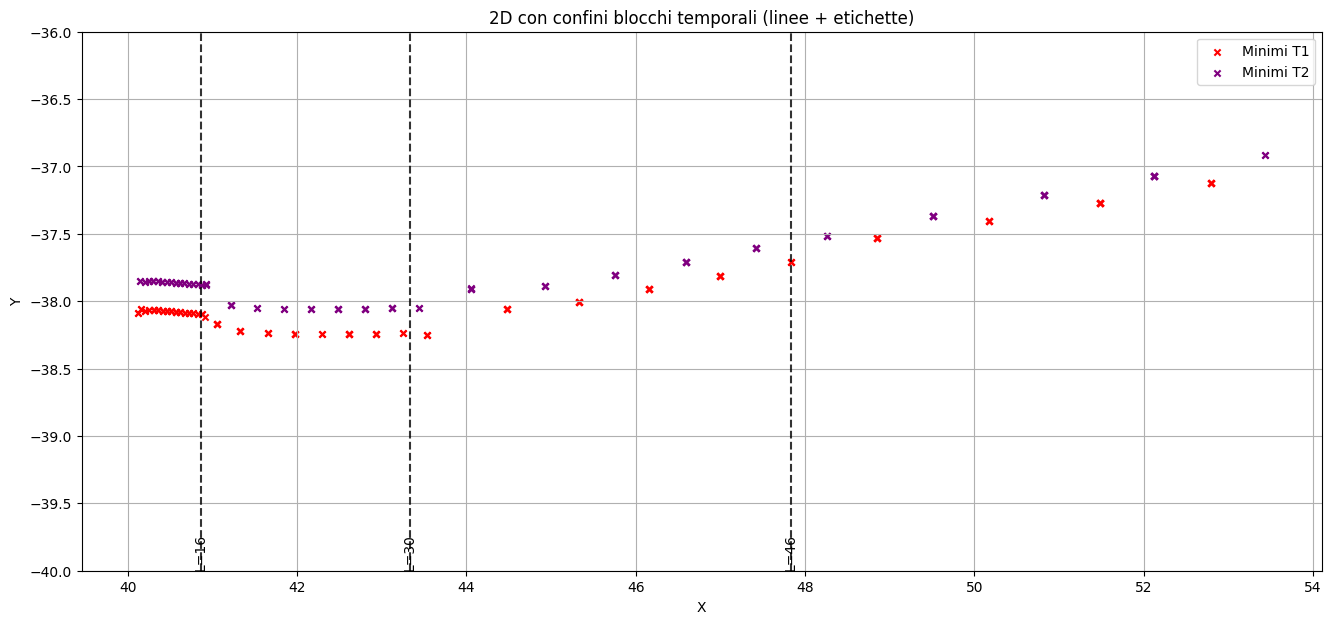

In [248]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy
x1_np = x1.detach().cpu().numpy()
y1_np = y1.detach().cpu().numpy()

T = len(x1_np)
BLOCK = 250

# punti in cui cambia blocco
boundaries = np.arange(BLOCK, T, BLOCK)


plt.figure(figsize=(16, 7))

# Minimi
plt.scatter(x1_np[min_idx1], y1_np[min_idx1],
            color='red', s=20, label='Minimi T1', marker='x')
plt.scatter(x2_np[min_idx2], y2_np[min_idx2],
            color='purple', s=20, label='Minimi T2', marker='x')

# Confini blocchi temporali
BLOCK = 250
T = len(x1_np)
boundaries = np.arange(BLOCK, T, BLOCK)
L_values = [16, 30, 46, 60]

for i, b in enumerate(boundaries):
    x_line = x1_np[b]  # posizione X alla transizione di blocco
    
    # linea verticale
    plt.axvline(x=x_line, color='black', linestyle='--', alpha=0.8)
    
    # testo leggermente sopra il range del plot
    plt.text(
        x_line, 
        -40,      # scegli tu la coordinata Y dove posizionare il testo
        f"L={L_values[i]}",  # testo da mostrare
        rotation=90,
        fontsize=10,
        va='bottom', ha='center'
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.ylim(-40, -36)
plt.title("2D con confini blocchi temporali (linee + etichette)")
plt.legend()
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


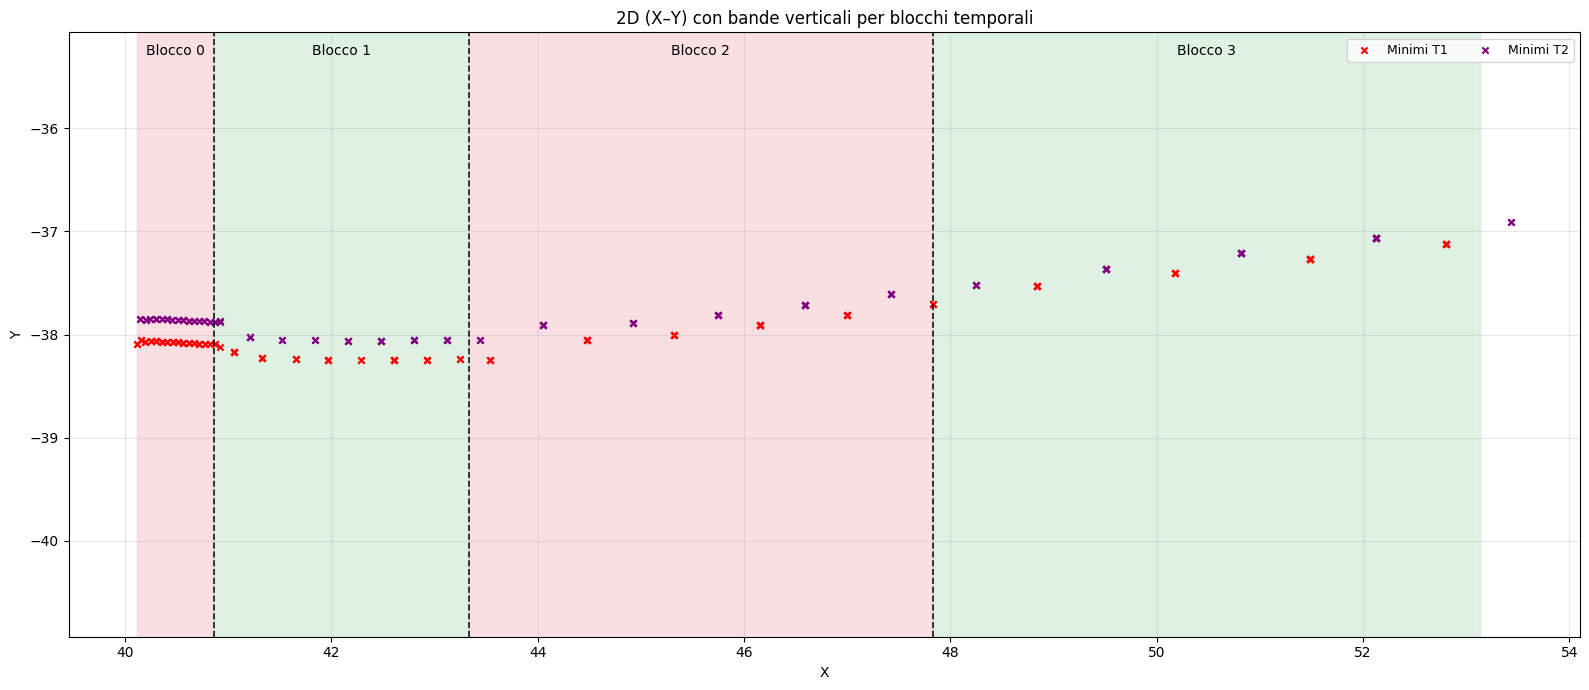

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# supponiamo che x1, y1, min_idx1, min_idx2, vx, vy siano già definiti
# e che x1, y1 siano tensori/array allineati nel tempo
to_np = lambda t: t.detach().cpu().numpy() if hasattr(t, "detach") else np.asarray(t)
x1_np = to_np(x1)
y1_np = to_np(y1)
x2_np = to_np(x2)
y2_np = to_np(y2)

# parametri blocchi temporali
BLOCK = 250
T = len(x1_np)
boundaries_t = np.arange(BLOCK, T, BLOCK)  # 250, 500, 750, ...

L_values = [ 16, 30, 46, 60]
v_values = [ 0.2, 0.6, 1.0, 1.4]

# converti i confini temporali in coordinate X del robot
# (le "linee" saranno agli x corrispondenti al cambio blocco)
x_boundaries = x1_np[boundaries_t]

fig, ax = plt.subplots(figsize=(16, 7))

# --- scatter dei minimi (come avevi)
ax.scatter(x1_np[min_idx1], y1_np[min_idx1],
           color='red', s=20, label='Minimi T1', marker='x')
ax.scatter(x2_np[min_idx2], y2_np[min_idx2],
           color='purple', s=20, label='Minimi T2', marker='x')

# (opzionale) traiettorie
# ax.plot(x1_np, y1_np, color='C0', alpha=0.3, label='Traiettoria 1')
# ax.plot(x2_np, y2_np, color='C1', alpha=0.3, label='Traiettoria 2')

# -------------------------------------------------------
# Bande verticali tra i confini (con alpha alto)
# -------------------------------------------------------
# Prepariamo gli "spigoli" includendo anche l'inizio e la fine:
x_edges = np.concatenate(([x1_np[0]], x_boundaries, [x1_np[-1]]))

# Per riempire tutta l'altezza dell'asse Y indipendentemente da ylim,
# usiamo la trasformazione: x in dati, y in coordinate assi [0..1]
ax_transform = ax.get_xaxis_transform()  # (data, axes)

colors = ['#f5c6cb', '#c3e6cb']  # rosso chiaro / verde chiaro (ben distinti)
alpha_band = 0.55                 # opacità alta (0..1)

for i in range(len(x_edges) - 1):
    x0, x1_ = x_edges[i], x_edges[i+1]
    # disegna la banda
    ax.axvspan(x0, x1_, color=colors[i % len(colors)], alpha=alpha_band,
               ymin=0.0, ymax=1.0, transform=ax_transform, zorder=0)

    # etichetta del blocco al centro della banda (ruotata di 90° se preferisci)
    x_mid = 0.5 * (x0 + x1_)
    ax.text(x_mid, 0.98, f"L = {L_values[i]} and v = {v_values[i]}",
            ha='center', va='top', fontsize=10, color='k',
            transform=ax_transform)

# Linee verticali sui confini (sopra le bande)
for xb in x_boundaries:
    ax.axvline(x=xb, color='k', linestyle='--', linewidth=1.2, alpha=0.9)

# aspetto
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
ax.axis("equal")
ax.set_ylim(-40, -36)  # o quello che usi normalmente
ax.set_title("2D (X–Y) con bande verticali per blocchi temporali")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

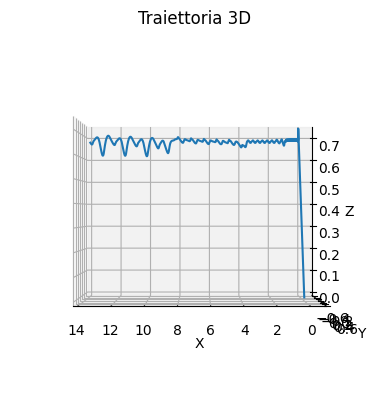

In [206]:
x = obs[env_id, :, -7].numpy()
y = obs[env_id, :, -6].numpy()
z = obs[env_id, :, -5].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Traiettoria 3D')

ax.view_init(elev=0, azim=90)
plt.show()

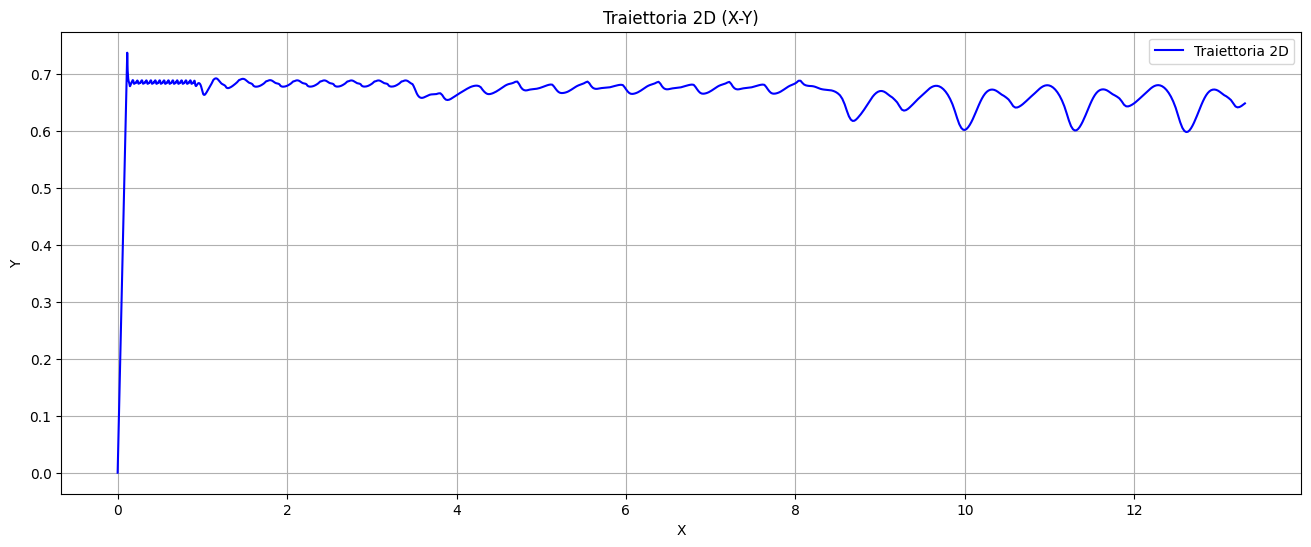

In [207]:


plt.figure(figsize=(16, 6))

plt.plot(x, z, label='Traiettoria 2D', color='blue')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Traiettoria 2D (X-Y)")
plt.grid(True)
# plt.axis("equal")   # preserva proporzioni reali
plt.legend()

plt.show()

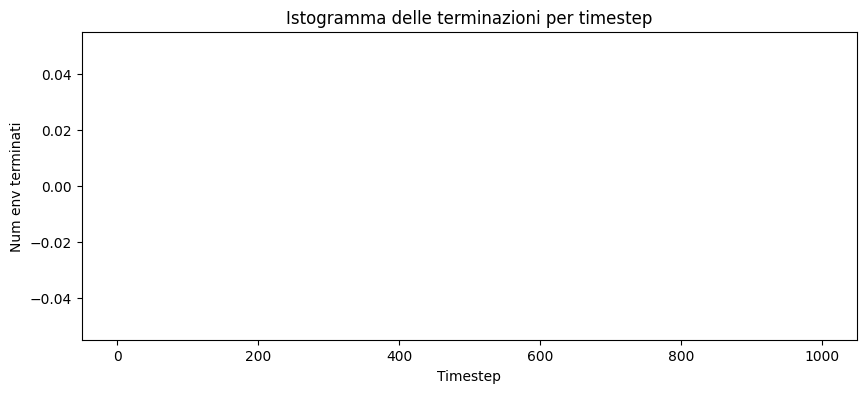

0.0


In [208]:

# terminateds: shape (num_envs, timesteps)
# esempio: tensore torch


# conta i terminati per timestep
terminations_per_timestep = truncated.sum(dim=0)  # shape (timesteps,)

plt.figure(figsize=(10,4))
plt.bar(range(terminated.shape[1]), terminations_per_timestep)
plt.xlabel("Timestep")
plt.ylabel("Num env terminati")
plt.title("Istogramma delle terminazioni per timestep")
plt.show()

total_terminations = truncated.sum().item()
print(total_terminations)


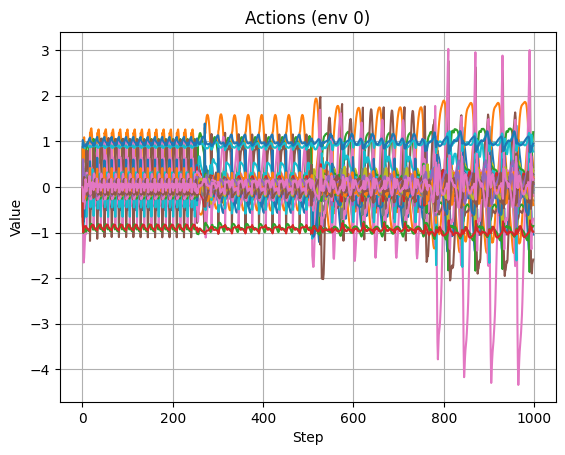

In [209]:

plt.plot(act[env_id, :, :])
plt.title(f"Actions (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()
